In [4]:
import os
import cv2
import pydicom
import pandas as pd
import numpy as np 
import tensorflow as tf 
import random

from tqdm.notebook import tqdm 
from typing import Sequence
import efficientnet.tfkeras as efn
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from PIL import Image
import h5py
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Dense, Dropout, Activation, Flatten, Input, BatchNormalization, GlobalAveragePooling2D, Add, Conv2D, AveragePooling2D, 
    LeakyReLU, Concatenate 
)
from tensorflow.keras import Model


0it [00:00, ?it/s]

A_slope: {}
TAB: {}
Amount of Patient identifier: 176
Input shape of EfficientNet: (None, 512, 512, 1)
Output shape of EfficientNet: (None, 16, 16, 2048)
Shape of 'x' tensor: (None, 2048)
Shape of 'x' tensor after dropout: (None, 2048)
Shape of 'x2' tensor: (None, 7)
Shape of 'x' tensor: (None, 2055)

Weights generated successfully.
Number of models: 1


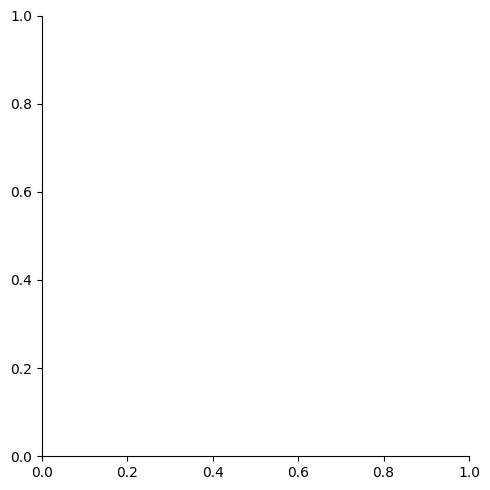

Number of unique patient identifiers in the test set: 5
Processing Patient ID: ID00224637202259281193413
Shape of 'x' (image data) for patient ID00224637202259281193413: (35, 512, 512)
Shape of 'tab' (tabular data) for patient ID00224637202259281193413: (35, 7)
Shape of 'x' after expanding dimensions for patient ID00224637202259281193413: (35, 512, 512, 1)
2/2 [==============================] - 8s 598ms/step
Shape of model output '_a' for patient ID00224637202259281193413: (35, 1)


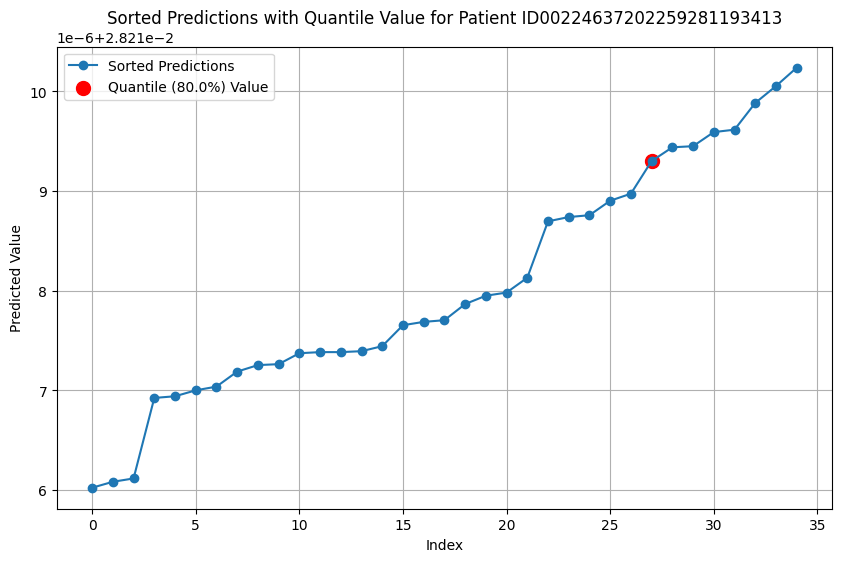





0.028219328820705415




[2810.44793691]




[60.15745336]




[55]
Processing Patient ID: ID00285637202278913507108
Shape of 'x' (image data) for patient ID00285637202278913507108: (20, 512, 512)
Shape of 'tab' (tabular data) for patient ID00285637202278913507108: (20, 7)
Shape of 'x' after expanding dimensions for patient ID00285637202278913507108: (20, 512, 512, 1)
1/1 [==============================] - 4s 4s/step
Shape of model output '_a' for patient ID00285637202278913507108: (20, 1)


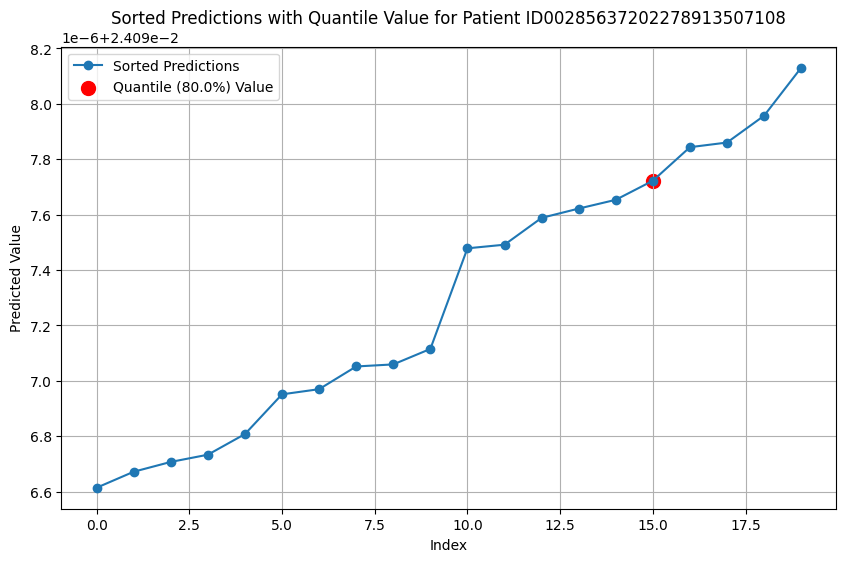





0.02409774623811245




[1302.60233072]




[61.37337036]




[58]
Processing Patient ID: ID00051637202185848464638
Shape of 'x' (image data) for patient ID00051637202185848464638: (79, 512, 512)
Shape of 'tab' (tabular data) for patient ID00051637202185848464638: (79, 7)
Shape of 'x' after expanding dimensions for patient ID00051637202185848464638: (79, 512, 512, 1)
3/3 [==============================] - 15s 4s/step
Shape of model output '_a' for patient ID00051637202185848464638: (79, 1)


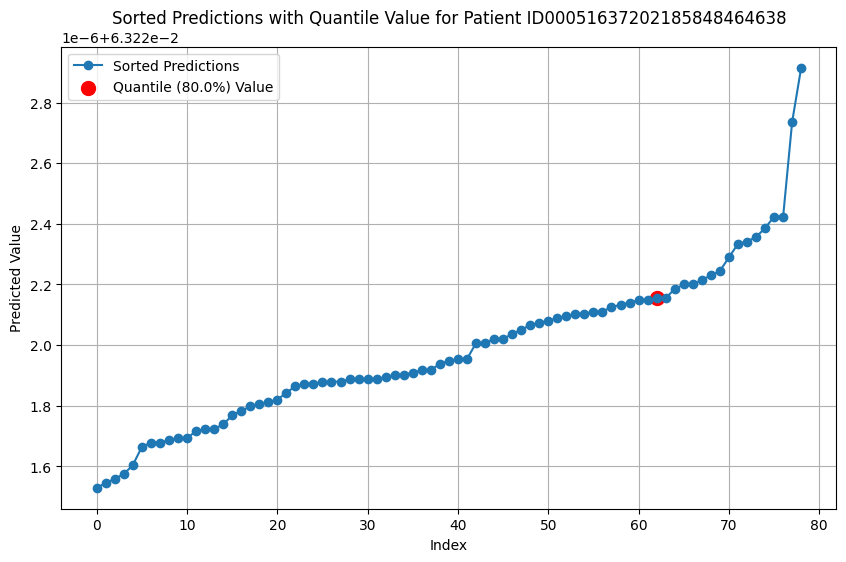





0.06322215497493744




[1528.58600363]




[73.70700024]




[54]
Processing Patient ID: ID00168637202237852027833
Shape of 'x' (image data) for patient ID00168637202237852027833: (165, 512, 512)
Shape of 'tab' (tabular data) for patient ID00168637202237852027833: (165, 7)
Shape of 'x' after expanding dimensions for patient ID00168637202237852027833: (165, 512, 512, 1)
6/6 [==============================] - 35s 6s/step
Shape of model output '_a' for patient ID00168637202237852027833: (165, 1)


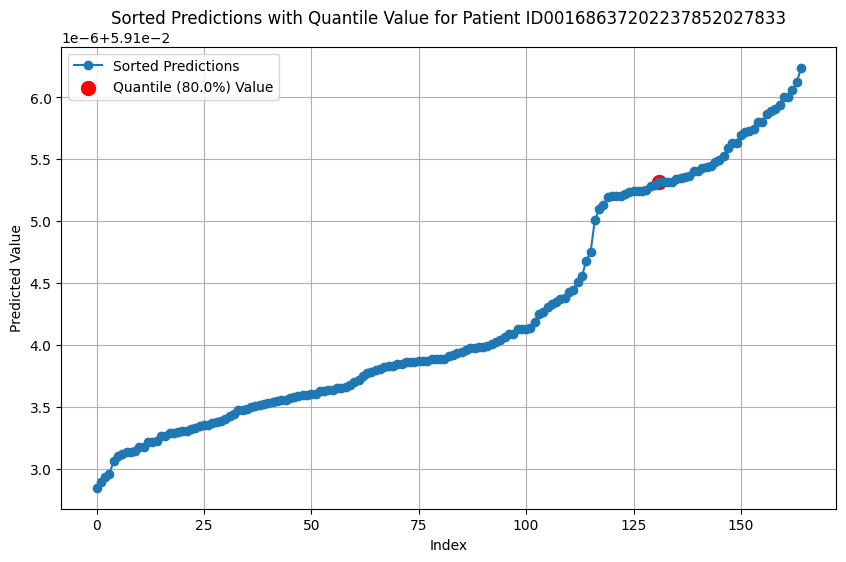





0.05910531431436539




[2707.45368114]




[67.5588118]




[60]
Processing Patient ID: ID00127637202219096738943
Shape of 'x' (image data) for patient ID00127637202219096738943: (32, 512, 512)
Shape of 'tab' (tabular data) for patient ID00127637202219096738943: (32, 7)
Shape of 'x' after expanding dimensions for patient ID00127637202219096738943: (32, 512, 512, 1)
1/1 [==============================] - 6s 6s/step
Shape of model output '_a' for patient ID00127637202219096738943: (32, 1)


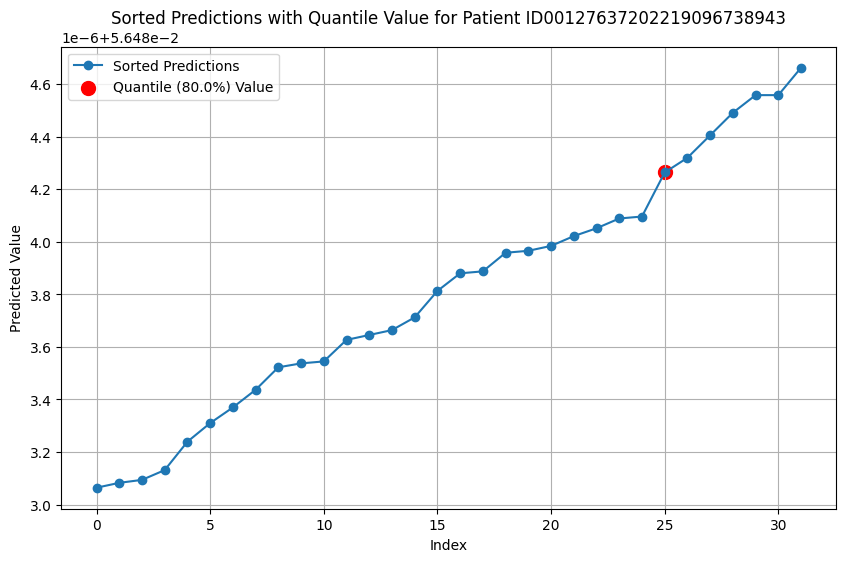





0.05648422986268997




[1545.35157701]




[60.90712743]




[100]


/var/folders/9q/pwqbdz21323f3j79799_2x7m0000gn/T/ipykernel_40590/931440398.py:295: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2810.10930497]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[sub.Patient_Week == k, 'FVC'] = fvc
/var/folders/9q/pwqbdz21323f3j79799_2x7m0000gn/T/ipykernel_40590/931440398.py:296: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[58.26675833]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[sub.Patient_Week == k, 'Confidence'] = (


0      2810.109305
1      1302.313158
2      1527.827338
3      2706.744417
4      1544.673766
          ...     
725    2814.201108
726    1305.807331
727    1536.994550
728    2715.314688
729    1552.863980
Name: FVC, Length: 730, dtype: float64


In [14]:
# Function to set seed for reproducibility(random number generator)

def seed_everything(seed=2020):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
seed_everything(42)

# Configuration for TensorFlow session
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

#supress tensorflow addons warning

train = pd.read_csv('osic-pulmonary-fibrosis-progression/train.csv') 

def get_tab(df):
    # Normalized age (scaled closer to 0-1)
    age_normalized = (df.Age.values[0] - 30) / 30
    
    # Gender: male: 0, female: 1
    sex = 0 if df.Sex.values[0] == 'male' else 1
    
    # Smoking status: never smoked: [0, 0], ex-smoker: [1, 1], currently smokes: [0, 1]
    if df.SmokingStatus.values[0] == 'Never smoked':
        smoking_status = [0, 0]
    elif df.SmokingStatus.values[0] == 'Ex-smoker':
        smoking_status = [1, 1]
    elif df.SmokingStatus.values[0] == 'Currently smokes':
        smoking_status = [0, 1]
    else:
        smoking_status = [1, 0]  # Considered as unknown or missing data, handling as [1, 0] arbitrarily

    # Normalize Weeks, FVC, Percent with epsilon to prevent division by zero
    epsilon = 1e-8
    weeks_range = df.Weeks.max() - df.Weeks.min()
    fvc_range = df.FVC.max() - df.FVC.min()
    percent_range = df.Percent.max() - df.Percent.min()

    weeks_normalized = (df.Weeks.values[0] - df.Weeks.min()) / (weeks_range if weeks_range > 0 else epsilon)
    fvc_normalized = (df.FVC.values[0] - df.FVC.min()) / (fvc_range if fvc_range > 0 else epsilon)
    percent_normalized = (df.Percent.values[0] - df.Percent.min()) / (percent_range if percent_range > 0 else epsilon)

    # Combine all features into a single vector
    vector = [age_normalized, sex] + smoking_status + [weeks_normalized, fvc_normalized, percent_normalized]
    return np.array(vector)

A_slope = {} # computed value (slope'a') for each patient
TAB = {} # tabular data for each patient
P = [] # unique patient identifiers

for i, p in tqdm(enumerate(train.Patient.unique())):
    #sub = train.loc[train.Patient == p, :] 
    #fvc = sub.FVC.values
    #weeks = sub.Weeks.values
    #c = np.vstack([weeks, np.ones(len(weeks))]).T
    #a, b = np.linalg.lstsq(c, fvc, rcond=None)[0] #fvc=a*weeks+b
    #a = how much FVC changes per week
    #b = constant (0), not used for this
    
    #A_slope[p] = a
    #TAB[p] = get_tab(sub)
    P.append(p)

print("A_slope:", A_slope)
print("TAB:", TAB)
print("Amount of Patient identifier:", len(P))

# read DICOM, normalized
def get_img(path):
    d = pydicom.dcmread(path)
    return cv2.resize(d.pixel_array / 2**11, (512, 512))

def get_efficientnet(model, shape):
    models_dict = {
        'b0': efn.EfficientNetB0(input_shape=shape,weights=None,include_top=False),
        'b1': efn.EfficientNetB1(input_shape=shape,weights=None,include_top=False),
        'b2': efn.EfficientNetB2(input_shape=shape,weights=None,include_top=False),
        'b3': efn.EfficientNetB3(input_shape=shape,weights=None,include_top=False),
        'b4': efn.EfficientNetB4(input_shape=shape,weights=None,include_top=False),
        'b5': efn.EfficientNetB5(input_shape=shape,weights=None,include_top=False),
        'b6': efn.EfficientNetB6(input_shape=shape,weights=None,include_top=False),
        'b7': efn.EfficientNetB7(input_shape=shape,weights=None,include_top=False)
    }
    efficientnet_model = models_dict[model]
    
    # Print input and output shapes
    input_shape = efficientnet_model.input_shape
    output_shape = efficientnet_model.output_shape
    print(f"Input shape of EfficientNet: {input_shape}")
    print(f"Output shape of EfficientNet: {output_shape}")
    

    return efficientnet_model


# Function to build the model
def build_model(shape=(512, 512, 1), model_class=None):
    inp = Input(shape=shape)
    base = get_efficientnet(model_class, shape)
    x = base(inp)
    x = GlobalAveragePooling2D()(x)

    x_shape = x.shape 
    print("Shape of 'x' tensor:", x_shape)  
    
    x = Dropout(0.5)(x)  
    print("Shape of 'x' tensor after dropout:", x.shape)  
    inp2 = Input(shape=(7,))  # Changed from (4,) to (7,)
    x2 = tf.keras.layers.GaussianNoise(0.2)(inp2)
    x2_shape = x2.shape 
    print("Shape of 'x2' tensor:", x2_shape)  

    x = Concatenate()([x, x2]) 
    x_shape = x.shape  
    print("Shape of 'x' tensor:", x_shape) 

    x = Dense(1)(x)
    x_shape = x.shape  
    model = Model([inp, inp2] , x)

    return model

# Model classes to build
model_classes = ['b5'] #['b0','b1','b2','b3',b4','b5','b6','b7']

# Initialize your models here
models = [build_model(shape=(512, 512, 1), model_class=m) for m in model_classes]


# Directory to save the weights
weights_directory = 'osic_model_weights'

# Ensure the directory exists
os.makedirs(weights_directory, exist_ok=True)

# Function to generate random weights
def generate_weights(model, model_class):
    # Generate random weights
    weights = [np.random.randn(*w.shape) for w in model.get_weights()]
    
    # Save weights to HDF5 file
    with h5py.File(os.path.join(weights_directory, f'{model_class}.h5'), 'w') as f:
        for i, w in enumerate(weights):
            f.create_dataset(f'weight_{i}', data=w)

# Generate weights for each model
for model, model_class in zip(models, model_classes):
    generate_weights(model, model_class)

print("\nWeights generated successfully.")
print('Number of models: ' + str(len(models)))

tr_p, vl_p = train_test_split(P,shuffle=True, train_size= 0.8) 

sns.displot(list(A_slope.values()))
plt.show()

# Caculate the score
def score(fvc_true, fvc_pred, sigma):
    sigma_clip = np.maximum(sigma, 70) # changed from 70, trie 66.7 too
    delta = np.abs(fvc_true - fvc_pred)
    delta = np.minimum(delta, 1000)
    sq2 = np.sqrt(2)
    metric = (delta / sigma_clip)*sq2 + np.log(sigma_clip* sq2)
    return np.mean(metric)


subs = []

for model in models:
    metric = []
    for q in tqdm(range(1, 10)):
        m = []
        for p in vl_p:
            x = [] 
            tab = [] 

            if p in ['ID00011637202177653955184', 'ID00052637202186188008618']:
                continue

            ldir = os.listdir(f'osic-pulmonary-fibrosis-progression/train/{p}/')
            for i in ldir:
                if int(i[:-4]) / len(ldir) < 0.8 and int(i[:-4]) / len(ldir) > 0.15:
                    x.append(get_img(f'osic-pulmonary-fibrosis-progression/train/{p}/{i}')) 
                    tab.append(get_tab(train.loc[train.Patient == p, :])) 
            if len(x) < 1:
                continue
            tab = np.array(tab) 

            x = np.expand_dims(x, axis=-1) 
            _a = model.predict([x, tab]) 
            a = np.quantile(_a, q / 10)

            percent_true = train.Percent.values[train.Patient == p]
            fvc_true = train.FVC.values[train.Patient == p]
            weeks_true = train.Weeks.values[train.Patient == p]

            fvc = a * (weeks_true - weeks_true[0]) + fvc_true[0]
            percent = percent_true[0] - a * abs(weeks_true - weeks_true[0])
            m.append(score(fvc_true, fvc, percent))
            mean_metric=np.mean(m)
            print(f"Model: {model_classes[models.index(model)]}, Quantile: {q/10}, Mean Metric: {mean_metric}")
        print(np.mean(m))
        metric.append(np.mean(m))

    q = (np.argmin(metric) + 1)/ 10
    #q=0.8

    sub = pd.read_csv('osic-pulmonary-fibrosis-progression/sample_submission.csv') 
    test = pd.read_csv('osic-pulmonary-fibrosis-progression/test.csv') 
    P_test = test.Patient.unique()

    print("Number of unique patient identifiers in the test set:", len(P_test))

    A_test, B_test, P_test,W, FVC= {}, {}, {},{},{} 
    STD, WEEK = {}, {} 
    quantile_values = []

    for p in test.Patient.unique():
        x = [] 
        tab = [] 
        ldir = os.listdir(f'osic-pulmonary-fibrosis-progression/test/{p}/')
        print(f"Processing Patient ID: {p}")

        for i in ldir:
            if int(i[:-4]) / len(ldir) < 0.8 and int(i[:-4]) / len(ldir) > 0.15:
                x.append(get_img(f'osic-pulmonary-fibrosis-progression/test/{p}/{i}')) 
                tab.append(get_tab(test.loc[test.Patient == p, :])) 
        if len(x) <= 1:
            continue
        tab = np.array(tab) 

        x = np.array(x)
        tab = np.array(tab)

        # Printing shapes of inputs
        print(f"Shape of 'x' (image data) for patient {p}:", x.shape)
        print(f"Shape of 'tab' (tabular data) for patient {p}:", tab.shape)

        x = np.expand_dims(x, axis=-1)  # Add a channel dimension to image data
        print(f"Shape of 'x' after expanding dimensions for patient {p}:", x.shape)

        _a = model.predict([x, tab])
        print(f"Shape of model output '_a' for patient {p}:", _a.shape)
        a = np.quantile(_a, q)
        quantile_values.append(a)


        plt.figure(figsize=(10, 6))

        # Sort the predictions for a smoother line graph
        sorted_predictions = np.sort(_a.flatten())
        sorted_indices = np.argsort(_a.flatten())

        plt.plot(sorted_predictions, marker='o', label='Sorted Predictions')

        # Find the index of the quantile value in the sorted list
        closest_index = np.argmin(np.abs(sorted_predictions - a))
        # Highlight the quantile value
        plt.scatter(closest_index, sorted_predictions[closest_index], color='red', s=100, label=f'Quantile ({q * 100}%) Value')

        plt.title(f'Sorted Predictions with Quantile Value for Patient {p}')
        plt.xlabel('Index')
        plt.ylabel('Predicted Value')
        plt.grid(True)
        plt.legend()
        plt.show()

        A_test[p] = a
        print('\n\n\n')
        print(A_test[p])
        B_test[p] = test.FVC.values[test.Patient == p] - a*test.Weeks.values[test.Patient == p]
        print('\n\n\n')
        print(B_test[p])
        P_test[p] = test.Percent.values[test.Patient == p] 
        print('\n\n\n')
        print(P_test[p])

        WEEK[p] = test.Weeks.values[test.Patient == p]
        print('\n\n\n')
        print(WEEK[p])


    for k in sub.Patient_Week.values:
        # p=patiehtnID
        # w=week to predict
        p, w = k.split('_')
        w = int(w) 
        fvc = A_test[p] * w + B_test[p] 

        # b
        sub.loc[sub.Patient_Week == k, 'FVC'] = fvc
        sub.loc[sub.Patient_Week == k, 'Confidence'] = (
            P_test[p] - A_test[p] * abs(WEEK[p] - w) 
            # P_test[p]: % predicted FVC
            # A_test[p]: predicted change in FVC per week for patient p
            # WEEK[p]: initial week
            )
         
    sub.to_csv('sub.csv', index=False)
    _sub = sub[["Patient_Week","FVC","Confidence"]].copy()
    subs.append(_sub)


N = len(subs)
sub = subs[0].copy() # ref
sub["FVC"] = 0
sub["Confidence"] = 0
for i in range(N):
    sub["FVC"] += subs[i]["FVC"] * (1/N)
    print(sub["FVC"])
    sub["Confidence"] += subs[i]["Confidence"] * (1/N)

sub[["Patient_Week","FVC","Confidence"]].to_csv("submission_img.csv", index=False)
